In [46]:
from src.post_processing import PathWrangler
import polars as pl
from pathlib import Path
from collections import defaultdict
from ergochemics.draw import draw_reaction, draw_molecule
from ergochemics.mapping import get_reaction_center
from ergochemics.similarity import MolFeaturizer, ReactionFingerprinter
from rdkit import Chem
from IPython.display import display, SVG
import numpy as np
from hydra import initialize, compose

In [47]:
study = "/home/stef/quest_data/bottle/data/processed/260327_target_3hpa"
# study = "/projects/b1039/spn1560/bottle/data/processed/260327_target_3hpa"
# study = "/home/stef/quest_data/bottle/data/processed/260324_2_step_bi_akg_to_hopa"
known = "/home/stef/bottle/artifacts/known"
# out_dir = "/home/stef/bottle/artifacts/coa_mutase_paths"

Direct look at parquet files

In [18]:
with initialize(config_path="../conf/filepaths", version_base=None):
    filepaths = compose(config_name="filepaths")

In [48]:
cpds = pl.read_parquet(
    Path(study)  / "compounds.parquet"
)
cpds.head()

id,smiles,type,name
str,str,enum,str
"""07e48b419b37606b338ba3e838a8e5…","""Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O…","""helper""","""PYROPHOSPHATE_DONOR_CoF"""
"""4ea34a41c2091b9cd312119934909d…","""Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O…","""helper""","""PYROPHOSPHATE_ACCEPTOR_CoF"""
"""c1a94434194999200be197465c01c3…","""Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C…","""helper""","""FAD_CoF"""
"""37225a49e3ed17e65590fb5ed4d536…","""Cc1cc2c(cc1C)N(CC(O)C(O)C(O)CO…","""helper""","""FADH2_CoF"""
"""d149421ac53cc62325e84c1688210e…","""Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O…","""helper""","""PHOSPHATE_ACCEPTOR_CoF"""


In [19]:
mechinformed_am_krs = pl.scan_parquet(
    Path(filepaths.rxn_x_rule_mapping) / "mapped_known_reactions_x_mechinformed_rules.parquet",
).select(
    pl.col("rxn_id"),
    pl.col("am_smarts")
).collect()

rc_0_am_krs = pl.scan_parquet(
    Path(filepaths.rxn_x_rule_mapping) / "mapped_known_reactions_x_rc_plus_0_rules.parquet",
).select(
    pl.col("rxn_id"),
    pl.col("am_smarts")
).collect()

am_krs = mechinformed_am_krs.join(
    other=rc_0_am_krs,
    on="rxn_id",
    how="outer",
    coalesce=True,
    suffix="_rc0"
).drop_nulls()

_am_krs = am_krs.drop(
    *[col for col in am_krs.columns if col.endswith("_rc0")]
).with_row_index()

/tmp/ipykernel_2795/1367388298.py:15: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  am_krs = mechinformed_am_krs.join(


In [37]:
am_krs = mechinformed_am_krs.join(
    other=rc_0_am_krs,
    on="rxn_id",
    how="full",
    coalesce=True,

)
am_krs

rxn_id,am_smarts,am_smarts_right
str,str,str
"""4fc554b86bb64504ce3bb78f4c02ac…","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…"
"""4fe435c487c7b2dc720dff02a9af2d…",null,"""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…"
"""db3a4d53e3f2557babac4615ca5518…",null,"""[*:4][CH:3]([*:5])[SH:1].[*:7]…"
"""74aa76da460568ccddd08f17f78cd8…",null,"""[*:3][CH:2]([*:4])[S:1][S:5][C…"
"""40c96410b09d3b0ef8fb9420f28029…",null,"""[*:16][C:1](=[CH:2][c:17]1[c:1…"
…,…,…
"""8a51f47fc63c6f242ff9969b8d66dc…","""[NH2:8][C:7](=[O:9])[c:1]1[cH:…",null
"""f437e093cc54767d69ce4ba0af6c3a…","""[O:19]=[c:17]1[nH:20][c:18](=[…",null
"""db2028e07cc847b4703eb34787c780…","""[O:9]=[P:1]([OH:3])([OH:2])[OH…",null


In [ ]:
am_krs.unpivot(
    
)

In [45]:
am_krs_ = pl.concat(
    [
        rc_0_am_krs, mechinformed_am_krs
    ]
)
am_krs_.unique().shape

(31489, 2)

a5e65fd

In [39]:
import polars as pl

# Sample DataFrame
df = pl.DataFrame({
    "date": ["2001-01-01", "2001-01-02"],
    "A": [1.0, 2.0],
    "B": [3.0, 4.0]
})

# Unpivot
result = df.unpivot(
    index="date",
    on=["A", "B"],
    variable_name="variable",
    value_name="value"
)
df.head()


date,A,B
str,f64,f64
"""2001-01-01""",1.0,3.0
"""2001-01-02""",2.0,4.0


In [40]:
result.head()

date,variable,value
str,str,f64
"""2001-01-01""","""A""",1.0
"""2001-01-02""","""A""",2.0
"""2001-01-01""","""B""",3.0
"""2001-01-02""","""B""",4.0


In [49]:
paths = pl.read_parquet(
    Path(study) / "paths.parquet"
)
paths.head()

path_id,rxn_id,main_pdt_id,rxn_type,generation
str,str,str,enum,i32
"""47a1438d3489cb7fec812cbf5a37cc…","""e864a2460aad26b50b2b7b1a20a46c…","""96d5f5730f91fd4cd27916fdc80c57…","""predicted""",2
"""64dbff5f8f8da63dd0dd3c8818be01…","""6d4c381d28cf5ff372d29533ed6fc8…","""b0001eb16d04bc19c4e985a7f4be99…","""predicted""",1
"""8feddd28c455968730bb4990c7c91c…","""f44411728cb6e44bee58bc7595c6a4…","""447a1970c3bccbdfee46a465b172b1…","""predicted""",2
"""0f65411be70bf1d8331231e33b656f…","""3ca7439df427de8a3930ebbd6bffe3…","""c081b69e27756fa73d997c50bea43b…","""predicted""",0
"""2294fcf7b691fc4e3be5af85d682a1…","""99995f83f8897d1350e72f6a4cb6c4…","""6569ea8ebe9fdd8627adb76f7d942d…","""predicted""",4


In [50]:
path_stats = pl.read_parquet(
    Path(study) / "path_stats.parquet"
)
path_stats.head()

id,starters,targets,dg_opt,dg_err,starter_ids,target_ids,mdf,mean_max_rxn_sim,mean_mean_rxn_sim,min_max_rxn_sim,min_mean_rxn_sim,feasibility_frac
str,list[str],list[str],list[f32],list[f32],list[str],list[str],f32,f32,f32,f32,f32,f32
"""2ea6e3f59ea4c73b9f4fab9bba4c12…","[""succinate semialdehyde""]","[""3hpa""]","[-26.858536, -28.093834, … -19.884779]","[100000.0, 0.000004, … -6.1212e-7]","[""08f879db7795c02a060c52bbb8d218f994f8ec6d""]","[""6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d""]",19.884779,0.17771,0.155579,0.0,0.0,0.4
"""1d9a262b0eadd3df2b6cb637bb8c8c…","[""succinate semialdehyde""]","[""3hpa""]","[-29.16692, -485.284302, … -58.651493]","[100000.0, 0.000004, … 7.3705e-8]","[""08f879db7795c02a060c52bbb8d218f994f8ec6d""]","[""6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d""]",19.942921,0.362921,0.268229,0.0,0.0,0.6
"""6978786ab4b6cea8326b238fd03b9f…","[""succinate semialdehyde""]","[""3hpa""]","[-893.56958, -36.284046, … -37.501724]","[141421.359375, 0.00001, … -0.000003]","[""08f879db7795c02a060c52bbb8d218f994f8ec6d""]","[""6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d""]",19.888083,0.335293,0.243866,0.0,0.0,0.6
"""dad26e1f0dbe1e23cde38fd04d2cd3…","[""succinate semialdehyde""]","[""3hpa""]","[-496.451813, -36.010033, … -19.884779]","[-0.000032, 100000.0, … -0.000005]","[""08f879db7795c02a060c52bbb8d218f994f8ec6d""]","[""6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d""]",19.884779,0.353981,0.265025,0.0,0.0,0.8
"""ba40d84d3c13f0c33d6c9a07fd2488…","[""glutarate""]","[""3hpa""]","[-892.216187, -10.250151, … -13.86786]","[141421.359375, 3.9845e-7, … -4.1029e-7]","[""b9ba7b161a805b86845f8335241d5f8eee78526f""]","[""6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d""]",10.250151,0.330091,0.241155,0.0,0.0,0.4


In [53]:
path_stats.filter(pl.col("id").str.starts_with("473339f"))

id,starters,targets,dg_opt,dg_err,starter_ids,target_ids,mdf,mean_max_rxn_sim,mean_mean_rxn_sim,min_max_rxn_sim,min_mean_rxn_sim,feasibility_frac
str,list[str],list[str],list[f32],list[f32],list[str],list[str],f32,f32,f32,f32,f32,f32
"""473339f6f1cd78417a5c736ffe89ec…",[null],"[""3hpa""]","[31.20841, -59.364693, … 0.747625]","[-0.000167, 0.00002, … -9.6620e-7]","[""08e398f0b85928f13306e2b5ec00f94e2f5afa17""]","[""6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d""]",-31.20841,0.05,0.05,0.0,0.0,0.6


In [70]:
prids = paths.filter(pl.col("path_id").str.starts_with("473339f"))['rxn_id'].to_list()

In [76]:
am_smarts = pred_rxns.filter(pl.col("id").is_in(prids))['am_smarts'].to_list()

In [80]:
dir = "/home/stef/quest_data/bottle/data/raw/expansions/dev"
fwd = pl.read_parquet(
    Path(dir) / "fwd" /  "reactions.parquet"
)
fwd = fwd.filter(pl.col("am_smarts").is_in(am_smarts))
fwd.write_parquet(
    Path(dir) / "fwd" /  "reactions_473339f.parquet"
)

rev = pl.read_parquet(
    Path(dir) / "rev" /  "reactions.parquet"
)
rev = rev.filter(pl.col("am_smarts").is_in(am_smarts))
rev.write_parquet(
    Path(dir) / "rev" /  "reactions_473339f.parquet"
)

In [81]:
fwd.head()

am_smarts,rule_name,rule_set,rule_template
str,str,str,str
"""[CH3:1][C:2](=[O:3])[CH2:4][CH…","""1533_0""","""mechinferred_dt_224_rules_w_co…","""[C&D1&v4&H3&+0&!R&z0:1]-[C&D3&…"
"""[NH2:1][C:2](=[O:3])[C:4]1=[CH…","""3788_1""","""mechinferred_dt_224_rules_w_co…","""[C&D3&v4&H0&+0&R&z0:1]1=[C&D2&…"


In [54]:
cpds.filter(pl.col("id") == "08e398f0b85928f13306e2b5ec00f94e2f5afa17")

id,smiles,type,name
str,str,enum,str
"""08e398f0b85928f13306e2b5ec00f9…","""CC(=O)CC=O""","""checkpoint""",null
"""08e398f0b85928f13306e2b5ec00f9…","""CC(=O)CC=O""","""checkpoint""",null


In [57]:
for row in cpds.filter(pl.col("type") == "source").iter_rows(named=True):
    print(row)

{'id': 'fae11404b12230ded37cfd2511bf3dd98bdacd3c', 'smiles': 'O=C(O)CCC(=O)O', 'type': 'source', 'name': 'succinate'}
{'id': '55e7ca03fb953e89747496916800481ee5f52b4a', 'smiles': 'O=C(O)C=CC(=O)O', 'type': 'source', 'name': 'fumarate'}
{'id': '77d21e11cc906a4c9614c97db30147761a24e690', 'smiles': 'O=C(O)CC(O)C(=O)O', 'type': 'source', 'name': 'malate'}
{'id': '20e696beb1325772afccb7eb1d2c187c70696753', 'smiles': 'O=C(O)CC(=O)C(=O)O', 'type': 'source', 'name': 'oxaloacetate'}
{'id': '6cf6db1d70f43061de31deeb417214c6fd7ad005', 'smiles': 'O=C(O)CCC(=O)C(=O)O', 'type': 'source', 'name': 'ketoglutarate'}
{'id': '18fadf6d3e42e06b2a32e2f706d8769770ba95ca', 'smiles': 'O=C(O)CC(O)(CC(=O)O)C(=O)O', 'type': 'source', 'name': 'citrate'}
{'id': '2efe03c1b1595e5fedce6a3674dad82075142215', 'smiles': 'CC(=O)C(=O)O', 'type': 'source', 'name': 'pyruvate'}
{'id': '6a2307f86745c292bc504cdf358769d6ed6f1136', 'smiles': 'CC(=O)O', 'type': 'source', 'name': 'acetate'}
{'id': '173558aa0ed72d2e42e1bc71880f594c0e

In [5]:
print(paths.shape)
print(paths.unique().shape)
print(path_stats.shape)
print(path_stats.unique().shape)

(8, 5)
(8, 5)
(4, 13)
(4, 13)


In [55]:
pred_rxns = pl.read_parquet(
    Path(study) / "predicted_reactions.parquet"
)
print(pred_rxns.shape)
pred_rxns.head()

(1225, 9)


id,smarts,am_smarts,dxgb_label,rxn_sims,analogue_ids,rules,templates,rule_sets
str,str,str,i32,list[f32],list[str],list[str],list[str],list[str]
"""099f5b0b88b6fb0a4ff72ceb692b1f…","""CC(C)C(OO)C(=O)O>>CC(C)CC(=O)O…","""[CH3:1][CH:2]([CH3:3])[CH:4]([…",0,[],[],"[""3958_0_reversed"", ""3956_0_reversed""]","[""[C&D3&v4&H1&+0&!R&z1:1](-[O&D2&v2&H0&+0&!R:3]-[O&D1&v2&H1&+0&!R:4])-[C&D3&v4&H0&+0&!R&z2:2]>>[C&D2&v4&H2&+0&!R&z0:1]-[C&D3&v4&H0&+0&!R&z2:2].[O&D1&v2&H0&+0&!R:3]=[O&D1&v2&H0&+0&!R:4]"", ""[C&D3&v4&H1&+0&!R&z1:1]-[O&D2&v2&H0&+0&!R:2]-[O&D1&v2&H1&+0&!R:3]>>[C&D2&v4&H2&+0&!R&z0:1].[O&D1&v2&H0&+0&!R:2]=[O&D1&v2&H0&+0&!R:3]""]","[""mechinferred_dt_112_rules_w_coreactants"", ""mechinferred_dt_112_rules_w_coreactants""]"
"""d35b28364a2a66f84c6477bcab1ed6…","""CC(C)(C(=O)O)C(O)C(=O)O.O=P(O)…","""[CH3:1][C:2]([CH3:3])([C:4](=[…",0,[],[],"[""2477_1"", ""1333_1""]","[""[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D1&v2&H1&+0&!R:3].[O&D1&v2&H0&+0&!R:4]=[P&D4&v5&H0&+0&!R:5](-[O&D1&v2&H1&+0&!R:6])(-[O&D1&v2&H1&+0&!R:7])-[O&D2&v2&H0&+0&!R:8]-[P&D4&v5&H0&+0&!R:9](=[O&D1&v2&H0&+0&!R:10])(-[O&D1&v2&H1&+0&!R:11])-[O&D1&v2&H1&+0&!R:12]>>[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D2&v2&H0&+0&!R:8]-[P&D4&v5&H0&+0&!R:9](=[O&D1&v2&H0&+0&!R:10])(-[O&D1&v2&H1&+0&!R:11])-[O&D1&v2&H1&+0&!R:12].[O&D1&v2&H0&+0&!R:4]=[P&D4&v5&H0&+0&!R:5](-[O&D1&v2&H1&+0&!R:3])(-[O&D1&v2&H1&+0&!R:6])-[O&D1&v2&H1&+0&!R:7]"", ""[O&D1&v2&H0&+0&!R:1]=[P&D4&v5&H0&+0&!R:2](-[O&D1&v2&H1&+0&!R:3])(-[O&D1&v2&H1&+0&!R:4])-[O&D2&v2&H0&+0&!R:5]-[P&D4&v5&H0&+0&!R:6](=[O&D1&v2&H0&+0&!R:7])(-[O&D1&v2&H1&+0&!R:8])-[O&D1&v2&H1&+0&!R:9].[O&D1&v2&H1&+0&!R:10]>>[O&D1&v2&H0&+0&!R:7]=[P&D4&v5&H0&+0&!R:6](-[O&D1&v2&H1&+0&!R:5])(-[O&D1&v2&H1&+0&!R:8])-[O&D1&v2&H1&+0&!R:9].[O&D2&v2&H0&+0&!R:10]-[P&D4&v5&H0&+0&!R:2](=[O&D1&v2&H0&+0&!R:1])(-[O&D1&v2&H1&+0&!R:3])-[O&D1&v2&H1&+0&!R:4]""]","[""mechinferred_dt_112_rules_w_coreactants"", ""mechinferred_dt_112_rules_w_coreactants""]"
"""f2d92933d782a58a0da8cfb2f9f89e…","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…","""[NH2:9][C:10](=[O:11])[C:12]1=…",1,"[0.863889, 0.863889, … 0.45036]","[""d4997d7878b88cc60bf6a798ee7fbf551e11cde9"", ""99f4a9341dd0e6fd965396e49671fba29fb3c540"", … ""9c3f3512d4e10713be22faca3e5a509018fbd7f8""]","[""4571_1_reversed""]","[""[C&D3&v4&H0&+0&R&z0:3]1=[C&D2&v4&H1&+0&R&z1:11]-[N&D3&v3&H0&+0&R:7](-[C&D3&v4&H1&+0&R&z2:8]-[C&D3&v4&H1&+0&R&z1:9]-[O&D1&v2&H1&+0&!R:10])-[C&D2&v4&H1&+0&R&z1:6]=[C&D2&v4&H1&+0&R&z0:5]-[C&D2&v4&H2&+0&R&z0:4]-1.[C&D3&v4&H1&+0&R&z2:1]-[O&D1&v2&H1&+0&!R:2]>>[C&D2&v4&H2&+0&R&z1:1].[O&D0&v2&H2&+0&!R:2].[c&D3&v4&H0&+0&R&z0:3]1:[c&D2&v4&H1&+0&R&z0:4]:[c&D2&v4&H1&+0&R&z0:5]:[c&D2&v4&H1&+0&R&z1:6]:[n&D3&v4&H0&+&R:7](-[C&D3&v4&H1&+0&R&z2:8]-[C&D3&v4&H1&+0&R&z1:9]-[O&D1&v2&H1&+0&!R:10]):[c&D2&v4&H1&+0&R&z1:11]:1""]","[""mechinferred_dt_112_rules_w_coreactants""]"
"""ad021343dd889ff42be7009421f633…","""Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O…","""[NH2:1][c:2]1[n:3][cH:4][n:5][…",0,"[0.063444, 0.063444, … 0.061947]","[""8c0d7892a6c762ecebf51738b6057cdb4c7251cc"", ""0d961adc677a663be5e7d89210c22845906cb22d"", … ""611b6268dc9cc5a06e33a3b8d0fa33c9fc0d06d1""]","[""1328_1_reversed""]","[""[C&D3&v4&H1&+0&R&z1:1]~[*:2]~[*:3]~[P&D4&v5&H0&+0&!R:4](-[O&D1&v2&H1&+0&!R:6])-[O&D1&v2&H1&+0&!R:5].[O&D2&v2&H0&+0&!R:11]-[S&D4&v6&H0&+0&!R:7](=[O&D1&v2&H0&+0&!R:8])(=[O&D1&v2&H0&+0&!R:9])-[O&D1&v2&H1&+0&!R:10]>>[C&D3&v4&H1&+0&R&z1:1]~[*:2]~[*:3]~[P&D4&v5&H0&+0&!R:4](-[O&D1&v2&H1&+0&!R:5])-[O&D2&v2&H0&+0&!R:6]-[S&D4&v6&H0&+0&!R:7](=[O&D1&v2&H0&+0&!R:8])(=[O&D1&v2&H0&+0&!R:9])-[O&D1&v2&H1&+0&!R:10].[O&D1&v2&H1&+0&!R:11]""]","[""mechinferred_dt_112_rules_w_coreactants""]"
"""646032df080e79e8522e14d05d8548…","""CC(C(=O)O)C(N)C(=O)O.CC(=O)SCC…","""[CH3:1][CH:2]([C:3](=[O:4])[OH…",1,[],[],"[""55_0""]","[""[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[O&D1&v2&H1&+0&!R:3].[S&D2&v2&H0&+0&!R:4]-[C&D3&v4&H0&+0&!R&z2:5]=[O&D1&v2&H0&+0&!R:6]>>[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])-[S&D2&v2&H0&+0&!R:4].[O&D1&v2&H0&+0&!R:6]=[C&D3&v4&H0&+0&!R&z2:5]-[O

In [10]:
krs = pl.read_parquet((Path(known) / "known_reactions.parquet"))
krs.head()

id,smarts,enzymes,reverse,db_ids
str,str,list[str],str,list[str]
"""e908a824c912d1e39c46de92d1f738…","""**.NC(CCC(=O)NC(CS)C(=O)NCC(=O…","[""P30109"", ""P57108"", … ""P46436""]","""3bbe8e6dca0da1c745e7678c8efebe…","[""RHEA:16438""]"
"""d86d99a8143d3be8fc861a5de5e625…","""*.*.*.*.*.*.*.*.*.*.CC(C)(COP(…","[""Q0UK48"", ""A0A0C6E0I7"", … ""A0A0C6DWS6""]","""e99fb0b75e799eba72aee21c1d04ee…","[""RHEA:51350""]"
"""2972b2db66715ba6f3d6aeaf07f31b…","""*.*.*.*.*.*.*.*.*NC(COP(=O)(O)…","[""G0REX6"", ""P0DO30"", ""A0A482N9V7""]","""5a7fffef224c65b7cd431ddc668eb2…","[""RHEA:64546""]"
"""572e4a84a946af07c9ab6fd1c0347b…","""*.*.*.*.*.*.*.*.*OP(=O)(O)OCC(…","[""Q6M083"", ""Q8U4J0"", … ""C5A6E5""]","""c4c936d8d985a457a128601b8d2769…","[""RHEA:64377""]"
"""dfe7fc761de3c213bf2b18fae4f8a5…","""*.*.*.*.*.*.*.*.CC(C)CCCC(C)CC…","[""Q6M083"", ""Q8U4J0"", … ""C5A6E5""]","""2e026380a550baa6b343604e6f5500…","[""RHEA:64369""]"


In [61]:
row = pred_rxns.filter(pl.col("id").str.starts_with("463c4c0"))
row['smarts'].item()

'O=CCCCO.NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1.O=O>>O=C(O)CCCO.O.NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)c1'

In [62]:
cpds.filter(pl.col("smiles") == "O=CCCCO")

id,smiles,type,name
str,str,enum,str
"""d53575bf0e2882579565d183b29ebc…","""O=CCCCO""","""checkpoint""",null
"""d53575bf0e2882579565d183b29ebc…","""O=CCCCO""","""checkpoint""",null


In [20]:
def get_rc_patts(am_rxn: str) -> tuple[str, str]:
    ''' Get reaction center pattern SMILES (left and right) from an atom-mapped reaction.'''
    sort_side = lambda side: ".".join(sorted(side.split(".")))
    lrc_idx, rrc_idx = get_reaction_center(am_rxn, mode="combined")
    lhs, rhs = [Chem.MolFromSmiles(smi) for smi in am_rxn.split(">>")]

    for mol in [lhs, rhs]:
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)

    lrc = Chem.MolFragmentToSmiles(lhs, lrc_idx)
    rrc = Chem.MolFragmentToSmiles(rhs, rrc_idx)

    lrc = sort_side(lrc)
    rrc = sort_side(rrc)
    return (lrc, rrc)

def tani_sim(X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
    ''' Compute Tanimoto similarity between two sets of fingerprints.'''
    A = X1 @ X2.T
    norms1 = X1.sum(axis=1).reshape(-1, 1)
    norms2 = X2.sum(axis=1).reshape(1, -1)
    N = norms1 + norms2
    S = A / (N - A)
    return S

def rcmfp_S(left: pl.DataFrame, right: pl.DataFrame, use_rc: bool, filter_by_rc: bool, radius: int, length: int, rc_dist_ub: int) -> np.ndarray:
    ''' 
    Compute RCMFP similarity matrix between the peirs of reactions 
    from the left and right dataframes.
    
    Args
    ----
    left: pd.DataFrame
        DataFrame containing the reactions with 'am_smarts' column
    right: pd.DataFrame
        DataFrame containing the reactions with 'am_smarts' column
    use_rc: bool
        Whether to use reaction center information in fingerprinting.
    filter_by_rc: bool
        Whether to filter similarity scores by reaction center patterns.
    radius: int
        Radius for fingerprinting.
    length: int
        Length of the fingerprint.
    rc_dist_ub: int
        Upper bound on bondwise distance from reaction center to consider in fingerprinting.

    Returns
    -------
    S: np.ndarray
        Similarity matrix of dimensions (len(left) x len(right))
    '''
    rxn_fper = ReactionFingerprinter(
        radius=radius,
        length=length,
        mol_featurizer=MolFeaturizer(),
    )

    left_rc_patts = []
    left_fps = []
    i = 0
    for row in left.iter_rows(named=True):
        smi = row['am_smarts']
        rc_patt = get_rc_patts(smi)
        left_rc_patts.append(rc_patt)
        fp = rxn_fper.fingerprint(smi, use_rc=use_rc, rc_dist_ub=rc_dist_ub)
        left_fps.append(fp)
        i += 1

    left_fps = np.vstack(left_fps).astype(np.float32)
    
    right_rc_patts = []
    right_fps = []
    i = 0
    for row in right.iter_rows(named=True):
        smi = row['am_smarts']
        rc_patt = get_rc_patts(smi)
        right_rc_patts.append(rc_patt)
        fp = rxn_fper.fingerprint(smi, use_rc=use_rc, rc_dist_ub=rc_dist_ub)
        right_fps.append(fp)
        i += 1

    right_fps =  np.vstack(right_fps).astype(np.float32)
    d = right_fps.shape[1]
    right_fps_rev = np.concatenate([right_fps[:, d//2:], right_fps[:, :d//2]], axis=1)

    S1 = tani_sim(left_fps, right_fps)
    S2 = tani_sim(left_fps, right_fps_rev)
    S = np.maximum(S1, S2)

    if filter_by_rc:
        filtered_S = np.zeros_like(S)
        for i, patt_i in enumerate(left_rc_patts):
            for j, patt_j in enumerate(right_rc_patts):
                if patt_i == patt_j:
                    filtered_S[i, j] = S[i, j]
                    continue

                if tuple(reversed(patt_i)) == patt_j:
                    filtered_S[i, j] = S[i, j]
                    continue

        return filtered_S
    else:
        return S

In [21]:
S = rcmfp_S(
    left=row,
    right=rc_0_am_krs,
    use_rc=True,
    filter_by_rc=True,
    radius=3,
    length=2048,
    rc_dist_ub=None,
)

In [22]:
S[S > 0.0]

array([0.80493826, 0.80493826, 0.37320575, 0.37320575, 0.7985258 ,
       0.794686  , 0.7985258 , 0.794686  , 0.79462105, 0.79462105,
       0.79948586, 0.79948586, 0.8601583 , 0.80246913, 0.82188296,
       0.8601583 , 0.82188296, 0.80246913, 0.85106385, 0.8316327 ,
       0.8244275 , 0.82323235, 0.86702126, 0.83      , 0.8815789 ,
       0.8701299 , 0.8475452 , 0.8882834 , 0.9048913 , 0.84042555,
       0.8475452 , 0.8882834 , 0.9048913 , 0.82323235, 0.85106385,
       0.8244275 , 0.86702126, 0.83      , 0.8815789 , 0.8316327 ,
       0.8701299 , 0.84042555, 0.8227848 , 0.7906977 , 0.7420091 ,
       0.76112413, 0.7222222 , 0.63673466, 0.70179373, 0.7090909 ,
       0.79950494, 0.78125   , 0.7488152 , 0.63673466, 0.7193764 ,
       0.70179373, 0.7090909 , 0.7540603 , 0.7772397 , 0.75934577,
       0.731982  , 0.80246913, 0.7488152 , 0.7801932 , 0.70652175,
       0.80246913, 0.78708136, 0.826972  , 0.7222222 , 0.731982  ,
       0.8227848 , 0.78125   , 0.76112413, 0.75934577, 0.74200

In [23]:
_S = rcmfp_S(
    left=row,
    right=_am_krs,
    use_rc=True,
    filter_by_rc=True,
    radius=3,
    length=2048,
    rc_dist_ub=None,
)

In [24]:
_S[_S > 0.0]

array([], dtype=float32)

In [25]:
S_ = rcmfp_S(
    left=row,
    right=mechinformed_am_krs,
    use_rc=True,
    filter_by_rc=True,
    radius=3,
    length=2048,
    rc_dist_ub=None,
)

In [26]:
S_[S_ > 0.0]

array([], dtype=float32)

In [27]:
rc_0_am_krs.head()

rxn_id,am_smarts
str,str
"""4fc554b86bb64504ce3bb78f4c02ac…","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…"
"""4fe435c487c7b2dc720dff02a9af2d…","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…"
"""db3a4d53e3f2557babac4615ca5518…","""[*:4][CH:3]([*:5])[SH:1].[*:7]…"
"""74aa76da460568ccddd08f17f78cd8…","""[*:3][CH:2]([*:4])[S:1][S:5][C…"
"""40c96410b09d3b0ef8fb9420f28029…","""[*:16][C:1](=[CH:2][c:17]1[c:1…"


In [ ]:
display(SVG(draw_molecule()))

In [16]:
def get_rc_patts(am_rxn: str) -> tuple[str, str]:
    ''' Get reaction center pattern SMILES (left and right) from an atom-mapped reaction.'''
    sort_side = lambda side: ".".join(sorted(side.split(".")))
    lrc_idx, rrc_idx = get_reaction_center(am_rxn, mode="combined")
    lhs, rhs = [Chem.MolFromSmiles(smi) for smi in am_rxn.split(">>")]

    for mol in [lhs, rhs]:
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)

    lrc = Chem.MolFragmentToSmiles(lhs, lrc_idx)
    rrc = Chem.MolFragmentToSmiles(rhs, rrc_idx)

    lrc = sort_side(lrc)
    rrc = sort_side(rrc)
    return (lrc, rrc)

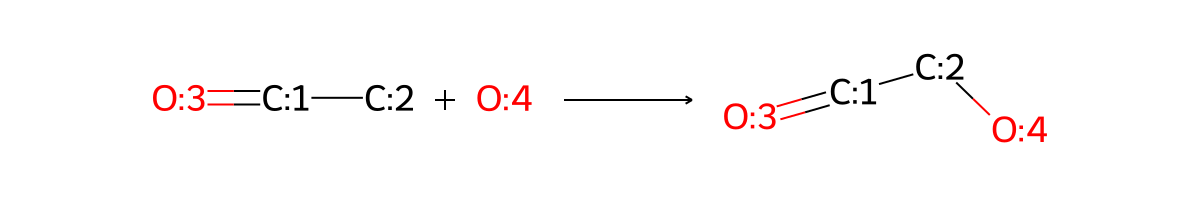

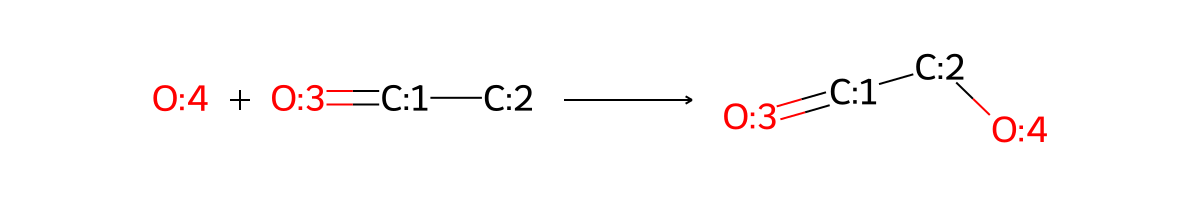

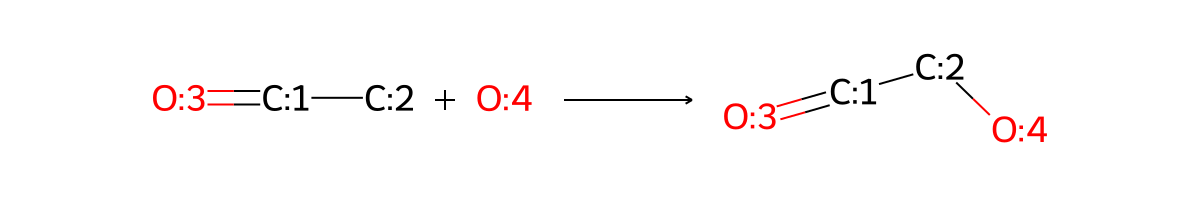

('[C].[O]', '[C][O]')
('[C].[O]', '[C][O]')
('[C].[O]', '[C][O]')


In [17]:
# Test permutation of reaction center function
amrxn1 = "[C:1](=[O:3])[C:2].[O:4]>>[C:1](=[O:3])[C:2][O:4]"
amrxn2 = "[O:4].[C:2][C:1](=[O:3])>>[C:1](=[O:3])[C:2][O:4]"
amrxn3 = "[C:2][C:1](=[O:3]).[O:4]>>[C:1](=[O:3])[C:2][O:4]"

display(SVG(draw_reaction(amrxn1)))
display(SVG(draw_reaction(amrxn2)))
display(SVG(draw_reaction(amrxn3)))

rc1 = get_rc_patts(amrxn1)
rc2 = get_rc_patts(amrxn2)
rc3 = get_rc_patts(amrxn3)
print(rc1)
print(rc2)
print(rc3)


Look via PathWrangler

In [ ]:
pw = PathWrangler(Path(study), Path(known))
tables = pw.get_paths()
paths = tables['paths']
krs = tables['known_reactions']
prs = tables['predicted_reactions']

pr2krs = dict(zip(prs['id'], prs['analogue_ids'].to_list()))
krs2enzymes = dict(zip(krs['id'], krs['enzymes'].to_list()))
prs2enzymes = defaultdict(list)
for p, ks in pr2krs.items():
    for k in ks:
        prs2enzymes[p] += krs2enzymes[k]

prs2smarts = dict(zip(prs['id'], prs['smarts'].to_list()))

paths = paths.select(
    pl.col("id"),
    pl.col("rxn_id"),
    (pl.col("generation") + 1).alias("step"),
    pl.col("starters").map_elements(lambda x : ";".join(x), return_dtype=pl.String),
    pl.col("targets").map_elements(lambda x : ";".join(x), return_dtype=pl.String),
    pl.col("rxn_id").replace_strict(prs2enzymes, default=[]).map_elements(lambda x : ";".join(x), return_dtype=pl.String).alias("enzymes"),
    pl.col("rxn_id").replace_strict(prs2smarts, default=None).alias("smarts")
)
paths

Formatting a pull for collaborators

In [ ]:
enzymes = tables['enzymes']


enzymes.with_columns(
    pl.col("id").map_elements(lambda x : f"https://www.uniprot.org/uniprotkb/{x}/entry", return_dtype=pl.String).alias("link"),
)

In [ ]:
paths.write_csv(
    Path(out_dir) / "250912_3hpa_paths.csv",
    separator=','
)

enzymes.write_csv(
    Path(out_dir) / "250912_3hpa_enzymes.csv",
    separator=','
)